<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 18px 28px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.2);">
    <h1 style="margin: 0; color: white; font-size: 26px; font-weight: 700; text-shadow: 1px 1px 2px rgba(0,0,0,0.3);">🌲 Swin Transformer — RealWaste Classifier</h1>
    <p style="margin: 8px 0 0 0; color: #c8e6c9; font-size: 14px;">Swin-B backbone · Shifted-window attention · 2-stage fine-tuning · Full evaluation pipeline</p>
</div>

In [1]:
!pip install -q torch torchvision scikit-learn seaborn tqdm
!pip install -q timm==0.9.2  # Swin models are available in timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.3 MB/s eta 0:00:00:00:01


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📚 2. Imports &amp; Seed</h2>
</div>

In [2]:
import os
import copy
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('PyTorch:', torch.__version__)
print('timm:', timm.__version__)

Device: cuda
PyTorch: 2.10.0+cu128
timm: 0.9.2


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📂 3. Locate Dataset Automatically</h2>
</div>

In [3]:
candidate_paths = [
    Path('/kaggle/input/datasets/sumn2u/garbage-classification-v2/original'),
    Path('/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_256'),
    Path('/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384'),
    Path('/kaggle/input/garbage-classification-v2/garbage-dataset'),
    Path('/kaggle/working/dataset'),
]

def is_dataset_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    class_dirs = [p for p in path.iterdir() if p.is_dir()]
    if len(class_dirs) < 2:
        return False
    has_images = any(
        any(c.glob('*.jpg')) or any(c.glob('*.jpeg')) or any(c.glob('*.png'))
        for c in class_dirs
    )
    return has_images

data_dir = None
for p in candidate_paths:
    if is_dataset_root(p):
        data_dir = p
        break

if data_dir is None:
    raise FileNotFoundError('No valid dataset root found. Update candidate_paths manually.')

print('Using dataset path:', data_dir)

Using dataset path: /kaggle/input/datasets/sumn2u/garbage-classification-v2/original


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📊 4. Build File Index and Inspect Class Balance</h2>
</div>

Total images: 12259
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


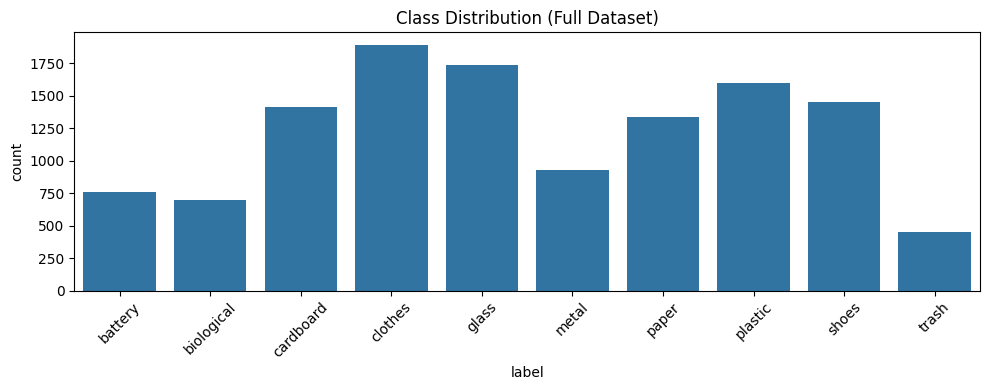

In [4]:
valid_ext = {'.jpg', '.jpeg', '.png'}
records = []

class_names = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}

for cls in class_names:
    cls_dir = data_dir / cls
    for img_path in cls_dir.rglob('*'):
        if img_path.suffix.lower() in valid_ext:
            records.append({
                'filepath': str(img_path),
                'label': cls,
                'label_idx': class_to_idx[cls]
            })

df = pd.DataFrame(records)
print('Total images:', len(df))
print('Classes:', class_names)

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='label', order=class_names)
plt.xticks(rotation=45)
plt.title('Class Distribution (Full Dataset)')
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">⚙️ 5. Stratified Train / Validation / Test Split</h2>
</div>

In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label_idx'],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label_idx'],
    random_state=SEED,
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = split['label'].value_counts().sort_index()
    print(f'\n{name} split class counts:')
    print(counts.to_string())

Train: 9807 | Val: 1226 | Test: 1226

Train split class counts:
label
battery        605
biological     559
cardboard     1129
clothes       1513
glass         1389
metal          744
paper         1069
plastic       1278
shoes         1159
trash          362

Val split class counts:
label
battery        75
biological     70
cardboard     141
clothes       190
glass         173
metal          93
paper         133
plastic       160
shoes         145
trash          46

Test split class counts:
label
battery        76
biological     70
cardboard     141
clothes       189
glass         174
metal          93
paper         134
plastic       159
shoes         145
trash          45


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🧪 6. Dataset Class and Transforms</h2>
</div>

**Swin-specific note:** Swin Transformer uses `224×224` by default. The `swin_base_patch4_window12_384` variant expects `384×384` — update `IMG_SIZE` and `BACKBONE` together if switching to the 384 model. We also add **RandAugment** for stronger regularisation, which helps the larger Swin-B model avoid overfitting on RealWaste.

In [6]:
# ── Config ──────────────────────────────────────────────────────────────────
# Swin variants available in timm:
#   swin_tiny_patch4_window7_224   (~28 M)  fast, good baseline
#   swin_small_patch4_window7_224  (~50 M)  balanced
#   swin_base_patch4_window7_224   (~88 M)  recommended ✅  (used below)
#   swin_base_patch4_window12_384  (~88 M)  higher-res, set IMG_SIZE=384
#   swin_large_patch4_window7_224  (~197 M) needs >16 GB VRAM

BACKBONE   = 'swin_base_patch4_window7_224'
IMG_SIZE   = 224   # change to 384 if using window12_384 variant
BATCH_SIZE = 32
NUM_WORKERS = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transforms ──────────────────────────────────────────────────────────────
# RandAugment + RandomErasing give Swin-B meaningful regularisation boosts.
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # slight over-size then crop
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandAugment(num_ops=2, magnitude=9),   # ← stronger augmentation
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),  # ← random erasing
])

val_test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class GarbageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = int(row['label_idx'])
        if self.transform:
            image = self.transform(image)
        return image, label


train_ds = GarbageDataset(train_df, transform=train_tfms)
val_ds   = GarbageDataset(val_df,   transform=val_test_tfms)
test_ds  = GarbageDataset(test_df,  transform=val_test_tfms)

print('Datasets ready.')

Datasets ready.


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">⚖️ 7. DataLoaders with Class-Imbalance Handling</h2>
</div>

In [7]:
train_labels = train_df['label_idx'].values
class_sample_count = np.array([np.sum(train_labels == t) for t in range(len(class_names))])
class_weights = 1.0 / np.maximum(class_sample_count, 1)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print('Loaders ready:', len(train_loader), len(val_loader), len(test_loader))

Loaders ready: 307 39 39


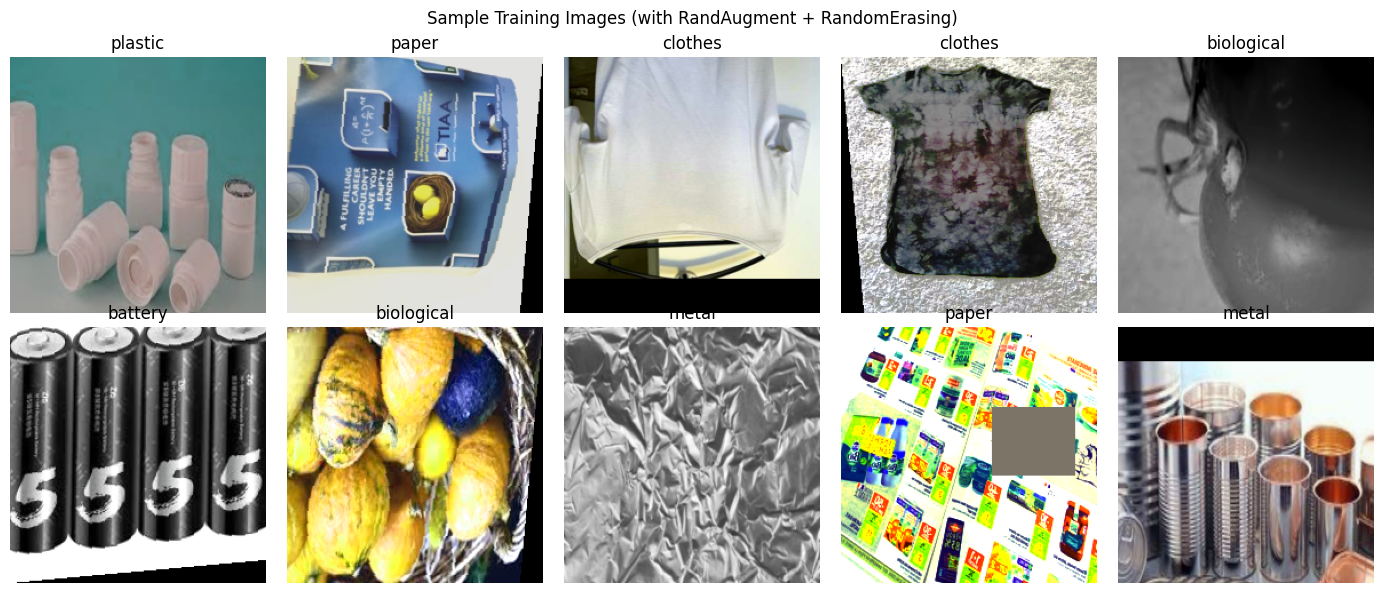

In [8]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    img = denormalize(images[i].cpu())
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(class_names[labels[i].item()])
    ax.axis('off')
plt.suptitle('Sample Training Images (with RandAugment + RandomErasing)')
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🌲 8. Build Swin Transformer Model</h2>
</div>

Swin Transformer uses **shifted-window self-attention** across 4 hierarchical stages, similar to how CNNs build from edges → textures → objects. This hierarchical design gives Swin strong locality bias — beneficial for distinguishing visually similar waste categories (e.g. plastic vs. glass).

In timm, Swin's classification head is `model.head` (a single `nn.Linear`). We freeze the backbone and only train the head in Stage 1.

In [9]:
def build_swin_model(
    backbone: str = 'swin_base_patch4_window7_224',
    num_classes: int = 10,
    freeze_features: bool = True,
    pretrained: bool = True,
):
    """
    Build a Swin Transformer model for image classification.

    Args:
        backbone        : timm model name, e.g. 'swin_base_patch4_window7_224'
        num_classes     : number of output classes
        freeze_features : if True, freeze all layers except the classification head
        pretrained      : load ImageNet-22k or ImageNet-1k pre-trained weights

    Returns:
        model (nn.Module)
    """
    model = timm.create_model(
        backbone,
        pretrained=pretrained,
        num_classes=num_classes,
    )

    if freeze_features:
        # Freeze everything first
        for p in model.parameters():
            p.requires_grad = False

        # Swin in timm exposes the head as model.head
        head = getattr(model, 'head', None)
        if head is None:
            head = getattr(model, 'classifier', None)
        if head is not None:
            for p in head.parameters():
                p.requires_grad = True
        else:
            # fallback: unfreeze last Linear
            for m in reversed(list(model.modules())):
                if isinstance(m, nn.Linear):
                    for p in m.parameters():
                        p.requires_grad = True
                    break

        # Also unfreeze norm layer (layer-norm before head) for better convergence
        norm = getattr(model, 'norm', None)
        if norm is not None:
            for p in norm.parameters():
                p.requires_grad = True

    return model


model = build_swin_model(
    backbone=BACKBONE,
    num_classes=len(class_names),
    freeze_features=True,
    pretrained=True,
).to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params       = sum(p.numel() for p in model.parameters())
print(f'Backbone        : {BACKBONE}')
print(f'Trainable params: {trainable_params:,} / {all_params:,}')
print(f'Frozen params   : {all_params - trainable_params:,}')
print(f'Model head      : {model.head}')

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Backbone        : swin_base_patch4_window7_224
Trainable params: 12,298 / 86,753,474
Frozen params   : 86,741,176
Model head      : ClassifierHead(
  (global_pool): SelectAdaptivePool2d (pool_type=avg, flatten=Identity())
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=1024, out_features=10, bias=True)
  (flatten): Identity()
)


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🛠️ 9. Training Utilities</h2>
</div>

Two improvements over the PVT notebook:
1. **Label smoothing** (`CrossEntropyLoss(label_smoothing=0.1)`) — reduces overconfidence, especially helpful with Swin-B's higher capacity.
2. **Cosine annealing** scheduler — smoother LR decay than `ReduceLROnPlateau`, commonly used in Swin training.

In [10]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses, accs = [], []
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        if hasattr(logits, 'logits'):
            logits = logits.logits
        loss = criterion(logits, targets)
        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, targets))
    return float(np.mean(losses)), float(np.mean(accs))


def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()
    losses, accs = [], []
    for images, targets in tqdm(loader, leave=False, desc='train'):
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()

        if scaler is not None:  # AMP mixed precision
            with torch.cuda.amp.autocast():
                logits = model(images)
                if hasattr(logits, 'logits'):
                    logits = logits.logits
                loss = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            if hasattr(logits, 'logits'):
                logits = logits.logits
            loss = criterion(logits, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, targets))
    return float(np.mean(losses)), float(np.mean(accs))


def fit(
    model,
    train_loader,
    val_loader,
    epochs=12,
    lr=1e-3,
    weight_decay=1e-4,
    patience=4,
    label_smoothing=0.1,
    use_cosine=True,
    use_amp=True,
):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )

    if use_cosine:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=lr * 0.01
        )
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.3, patience=2
        )

    # AMP scaler (only meaningful on CUDA)
    scaler = torch.cuda.amp.GradScaler() if (use_amp and device.type == 'cuda') else None

    history = []
    best_state    = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    no_improve    = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion)

        if use_cosine:
            scheduler.step()
        else:
            scheduler.step(val_loss)

        row = {
            'epoch':      epoch,
            'lr':         optimizer.param_groups[0]['lr'],
            'train_loss': train_loss,
            'train_acc':  train_acc,
            'val_loss':   val_loss,
            'val_acc':    val_acc,
        }
        history.append(row)
        print(
            f"Epoch {epoch:02d}/{epochs} | lr {row['lr']:.2e} | "
            f"train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | "
            f"val_loss {val_loss:.4f} | val_acc {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print('Early stopping triggered.')
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🚀 10. Train — Stage 1 (Head + Norm Only)</h2>
</div>

Stage 1 trains only the classification head (and final LayerNorm) with the Swin backbone fully frozen. This acts as a warm-up, giving the head a sensible initialisation before full fine-tuning.

In [11]:
EPOCHS_S1 = 10
LR_S1     = 1e-3

model, history_stage1 = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_S1,
    lr=LR_S1,
    weight_decay=1e-4,
    patience=4,
    label_smoothing=0.1,
    use_cosine=True,
    use_amp=True,
)

history_stage1.tail()

/tmp/ipykernel_55/2240170926.py:82: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device.type == 'cuda') else None


train:   0%|          | 0/307 [00:00<?, ?it/s]

/tmp/ipykernel_55/2240170926.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/10 | lr 9.76e-04 | train_loss 0.8324 | train_acc 0.9011 | val_loss 0.6609 | val_acc 0.9542


train:   0%|          | 0/307 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79644bb92ca0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79644bb92ca0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 09/10 | lr 3.42e-05 | train_loss 0.6493 | train_acc 0.9591 | val_loss 0.6221 | val_acc 0.9696


train:   0%|          | 0/307 [00:00<?, ?it/s]

Epoch 10/10 | lr 1.00e-05 | train_loss 0.6456 | train_acc 0.9637 | val_loss 0.6221 | val_acc 0.9688


,epoch,lr,train_loss,train_acc,val_loss,val_acc
5,6,0.000352,0.648689,0.960607,0.628920,0.966186
6,7,0.000214,0.650190,0.959589,0.624133,0.967949
7,8,0.000105,0.650674,0.959894,0.622222,0.971154
8,9,0.000034,0.649295,0.959080,0.622052,0.969551
9,10,0.000010,0.645611,0.963660,0.622070,0.968750


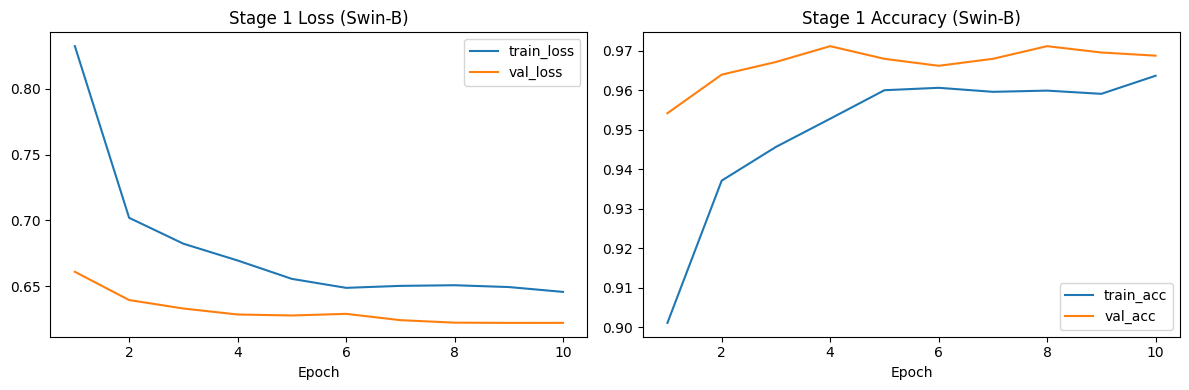

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_stage1['epoch'], history_stage1['train_loss'], label='train_loss')
axes[0].plot(history_stage1['epoch'], history_stage1['val_loss'],   label='val_loss')
axes[0].set_title('Stage 1 Loss (Swin-B)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_stage1['epoch'], history_stage1['train_acc'], label='train_acc')
axes[1].plot(history_stage1['epoch'], history_stage1['val_acc'],   label='val_acc')
axes[1].set_title('Stage 1 Accuracy (Swin-B)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🎯 11. Fine-Tuning — Stage 2 (Gradual Unfreeze)</h2>
</div>

We use **layer-wise learning rate decay (LLRD)** — deeper (earlier) Swin layers get a smaller LR, since their ImageNet features are already well-trained. This prevents catastrophic forgetting and is the standard approach for Swin fine-tuning.

| Layer group | LR decay factor | Effective LR |
|---|---|---|
| Head + Norm | 1.0× | `1e-4` |
| Stage 4 (last) | 0.9× | `9e-5` |
| Stage 3 | 0.81× | `~8.1e-5` |
| Stage 2 | 0.73× | `~7.3e-5` |
| Stage 1 + patch embed | 0.66× | `~6.6e-5` |

In [13]:
def get_swin_param_groups(model, base_lr=1e-4, lr_decay=0.9):
    """
    Build parameter groups with layer-wise LR decay for Swin Transformer.
    Swin stages: patch_embed → layers.0 → layers.1 → layers.2 → layers.3 → norm → head
    """
    # Unfreeze all first
    for p in model.parameters():
        p.requires_grad = True

    depth_map = {
        'head':        base_lr,
        'norm':        base_lr,
        'layers.3':    base_lr * (lr_decay ** 1),
        'layers.2':    base_lr * (lr_decay ** 2),
        'layers.1':    base_lr * (lr_decay ** 3),
        'layers.0':    base_lr * (lr_decay ** 4),
        'patch_embed': base_lr * (lr_decay ** 5),
    }

    groups = []
    assigned = set()
    for prefix, lr in depth_map.items():
        params = [
            p for n, p in model.named_parameters()
            if n.startswith(prefix) and id(p) not in assigned
        ]
        for n, p in model.named_parameters():
            if n.startswith(prefix):
                assigned.add(id(p))
        if params:
            groups.append({'params': params, 'lr': lr})
            print(f'  {prefix}: {len(params)} tensors @ lr={lr:.2e}')

    # Any remaining params (shouldn't be many)
    remaining = [p for n, p in model.named_parameters() if id(p) not in assigned]
    if remaining:
        groups.append({'params': remaining, 'lr': base_lr * (lr_decay ** 5)})
        print(f'  other: {len(remaining)} tensors @ lr={base_lr * lr_decay**5:.2e}')

    return groups


print('Building LLRD param groups:')
param_groups = get_swin_param_groups(model, base_lr=1e-4, lr_decay=0.9)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nAll {trainable:,} parameters now trainable.')

Building LLRD param groups:
  head: 2 tensors @ lr=1.00e-04
  norm: 2 tensors @ lr=1.00e-04
  layers.3: 29 tensors @ lr=9.00e-05
  layers.2: 237 tensors @ lr=8.10e-05
  layers.1: 29 tensors @ lr=7.29e-05
  layers.0: 26 tensors @ lr=6.56e-05
  patch_embed: 4 tensors @ lr=5.90e-05

All 86,753,474 parameters now trainable.


/tmp/ipykernel_55/2934248118.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler2 = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


train:   0%|          | 0/307 [00:00<?, ?it/s]

/tmp/ipykernel_55/2240170926.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


S2 Epoch 01/8 | lr 9.62e-05 | train_loss 0.6389 | train_acc 0.9569 | val_loss 0.5975 | val_acc 0.9639


train:   0%|          | 0/307 [00:00<?, ?it/s]

...

S2 Epoch 06/8 | lr 1.55e-05 | train_loss 0.5242 | train_acc 0.9934 | val_loss 0.5617 | val_acc 0.9768


train:   0%|          | 0/307 [00:00<?, ?it/s]

S2 Epoch 07/8 | lr 4.77e-06 | train_loss 0.5182 | train_acc 0.9953 | val_loss 0.5526 | val_acc 0.9800


train:   0%|          | 0/307 [00:00<?, ?it/s]

S2 Epoch 08/8 | lr 1.00e-06 | train_loss 0.5167 | train_acc 0.9954 | val_loss 0.5521 | val_acc 0.9808


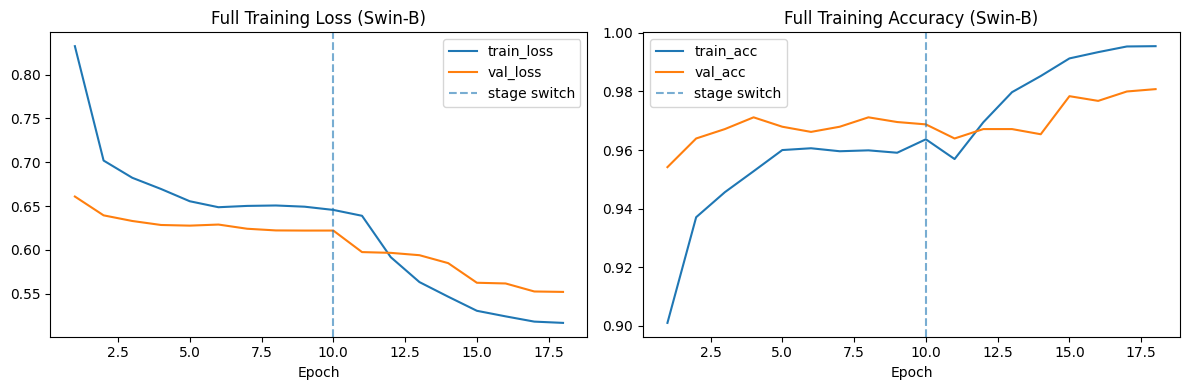

In [14]:
# ── Stage 2: Full fine-tuning with LLRD ──────────────────────────────────────
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer2 = torch.optim.AdamW(param_groups, weight_decay=1e-5)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=8, eta_min=1e-6
)
scaler2 = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

EPOCHS_S2 = 8
patience  = 4

history2 = []
best_state    = copy.deepcopy(model.state_dict())
best_val_loss = float('inf')
no_improve    = 0

for epoch in range(1, EPOCHS_S2 + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer2, scaler2)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler2.step()

    row = {
        'epoch':      epoch,
        'lr':         optimizer2.param_groups[0]['lr'],
        'train_loss': train_loss,
        'train_acc':  train_acc,
        'val_loss':   val_loss,
        'val_acc':    val_acc,
    }
    history2.append(row)
    print(
        f"S2 Epoch {epoch:02d}/{EPOCHS_S2} | lr {row['lr']:.2e} | "
        f"train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | "
        f"val_loss {val_loss:.4f} | val_acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = copy.deepcopy(model.state_dict())
        no_improve    = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print('Early stopping triggered.')
            break

model.load_state_dict(best_state)
history_stage2 = pd.DataFrame(history2)

# Merge both stages
h1 = history_stage1.copy()
h2 = history_stage2.copy()
if len(h2) > 0:
    h2['epoch'] = h2['epoch'] + h1['epoch'].max()
history_all = pd.concat([h1, h2], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_all['epoch'], history_all['train_loss'], label='train_loss')
axes[0].plot(history_all['epoch'], history_all['val_loss'],   label='val_loss')
axes[0].axvline(h1['epoch'].max(), linestyle='--', alpha=0.6, label='stage switch')
axes[0].set_title('Full Training Loss (Swin-B)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_all['epoch'], history_all['train_acc'], label='train_acc')
axes[1].plot(history_all['epoch'], history_all['val_acc'],   label='val_acc')
axes[1].axvline(h1['epoch'].max(), linestyle='--', alpha=0.6, label='stage switch')
axes[1].set_title('Full Training Accuracy (Swin-B)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📈 12. Test Set Evaluation</h2>
</div>

predicting:   0%|          | 0/39 [00:00<?, ?it/s]

Test Accuracy: 0.9796

Classification Report:
              precision    recall  f1-score   support

     battery     1.0000    0.9737    0.9867        76
  biological     1.0000    0.9857    0.9928        70
   cardboard     0.9722    0.9929    0.9825       141
     clothes     1.0000    0.9894    0.9947       189
       glass     0.9661    0.9828    0.9744       174
       metal     0.9574    0.9677    0.9626        93
       paper     0.9851    0.9851    0.9851       134
     plastic     0.9809    0.9686    0.9747       159
       shoes     0.9797    1.0000    0.9898       145
       trash     0.9286    0.8667    0.8966        45

    accuracy                         0.9796      1226
   macro avg     0.9770    0.9713    0.9740      1226
weighted avg     0.9796    0.9796    0.9795      1226



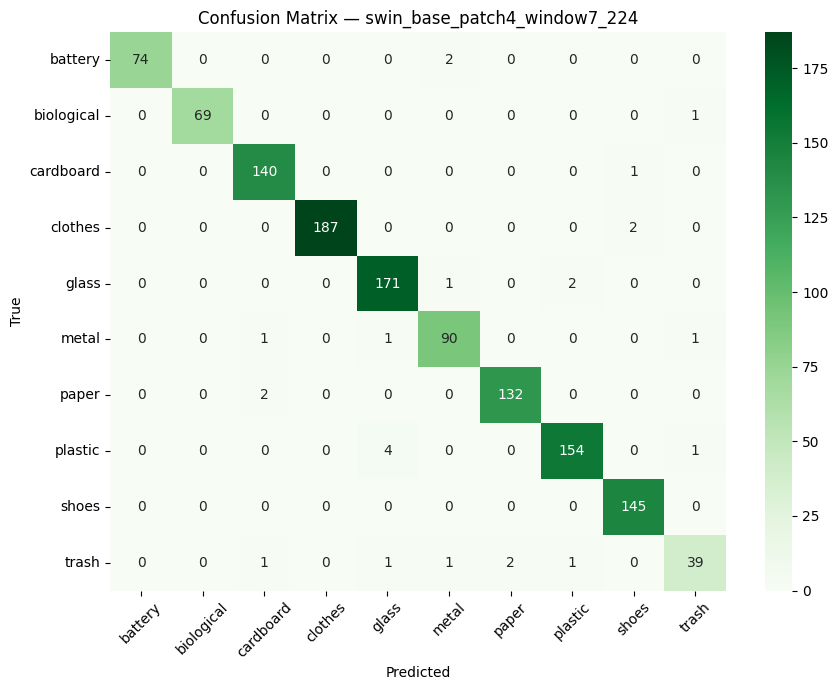

In [15]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in tqdm(loader, desc='predicting'):
        images = images.to(device)
        logits = model(images)
        if hasattr(logits, 'logits'):
            logits = logits.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.numpy().tolist())
    return np.array(all_targets), np.array(all_preds)


y_true, y_pred = predict_loader(model, test_loader)

test_acc = (y_true == y_pred).mean()
print(f'Test Accuracy: {test_acc:.4f}')

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names
)
plt.title(f'Confusion Matrix — {BACKBONE}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">📊 13. Detailed Metrics (Macro, Weighted, Per-Class)</h2>
</div>

In [16]:
overall_accuracy = accuracy_score(y_true, y_pred)
prec_macro,    rec_macro,    f1_macro,    _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

print('=== Overall Metrics ===')
print(f'Accuracy      : {overall_accuracy:.4f}')
print(f'Precision(Ma) : {prec_macro:.4f}')
print(f'Recall(Ma)    : {rec_macro:.4f}')
print(f'F1-Score(Ma)  : {f1_macro:.4f}')
print(f'Precision(Wt) : {prec_weighted:.4f}')
print(f'Recall(Wt)    : {rec_weighted:.4f}')
print(f'F1-Score(Wt)  : {f1_weighted:.4f}')

p, r, f1, s = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(len(class_names))), zero_division=0
)

metrics_df = pd.DataFrame({
    'class':     class_names,
    'precision': p,
    'recall':    r,
    'f1_score':  f1,
    'support':   s,
}).sort_values('f1_score', ascending=False)

print('\n=== Per-Class Metrics (sorted by F1) ===')
display(metrics_df.style.format({
    'precision': '{:.4f}',
    'recall':    '{:.4f}',
    'f1_score':  '{:.4f}',
}))

=== Overall Metrics ===
Accuracy      : 0.9796
Precision(Ma) : 0.9770
Recall(Ma)    : 0.9713
F1-Score(Ma)  : 0.9740
Precision(Wt) : 0.9796
Recall(Wt)    : 0.9796
F1-Score(Wt)  : 0.9795

=== Per-Class Metrics (sorted by F1) ===


,class,precision,recall,f1_score,support
3,clothes,1.0000,0.9894,0.9947,189
1,biological,1.0000,0.9857,0.9928,70
8,shoes,0.9797,1.0000,0.9898,145
0,battery,1.0000,0.9737,0.9867,76
6,paper,0.9851,0.9851,0.9851,134
2,cardboard,0.9722,0.9929,0.9825,141
7,plastic,0.9809,0.9686,0.9747,159
4,glass,0.9661,0.9828,0.9744,174
5,metal,0.9574,0.9677,0.9626,93
9,trash,0.9286,0.8667,0.8966,45


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🔍 14. Low-F1 Class Diagnostic &amp; Recommendations</h2>
</div>

In [17]:
threshold_f1  = 0.93
fallback_top_n = 3

low_f1_df  = metrics_df.sort_values('f1_score', ascending=True).copy()
flagged_df = low_f1_df[low_f1_df['f1_score'] < threshold_f1].copy()

if flagged_df.empty:
    flagged_df = low_f1_df.head(fallback_top_n).copy()

suggestion_map = {
    'trash':      'Increase samples + hard augmentations (random crop, blur, brightness/contrast).',
    'plastic':    'Add look-alike negatives (glass/metal) and stronger color/texture augmentation.',
    'metal':      'Add edge/reflective examples; train with higher-resolution images.',
    'paper':      'Add crumpled/wet variants and background diversity.',
    'glass':      'Include transparent/reflective cases with varied lighting.',
    'battery':    'Add close-up and distance variants; balance orientation examples.',
    'cardboard':  'Add folded/torn variants and cluttered backgrounds.',
    'shoes':      'Use occlusion augmentation and mixed-background samples.',
    'biological': 'Include decomposition/shape diversity and lighting changes.',
    'clothes':    'Add texture and color diversity with background clutter.',
}

flagged_df['gap_to_0.95'] = (0.95 - flagged_df['f1_score']).clip(lower=0)
flagged_df['recommended_action'] = flagged_df['class'].map(suggestion_map).fillna(
    'Use class-focused augmentation + collect more hard samples for this class.'
)

print(f'=== Low-F1 Class Diagnostic (threshold: {threshold_f1:.2f}) ===')
print(f'Flagged classes: {len(flagged_df)}')
display(
    flagged_df[['class', 'precision', 'recall', 'f1_score', 'support', 'gap_to_0.95', 'recommended_action']]
    .style
    .format({
        'precision':   '{:.4f}',
        'recall':      '{:.4f}',
        'f1_score':    '{:.4f}',
        'gap_to_0.95': '{:.4f}',
    })
)

print('\nQuick priority order (most urgent first):')
for _, row in flagged_df.sort_values('f1_score').iterrows():
    print(f"  - {row['class']}: F1={row['f1_score']:.4f} | {row['recommended_action']}")

=== Low-F1 Class Diagnostic (threshold: 0.93) ===
Flagged classes: 1


,class,precision,recall,f1_score,support,gap_to_0.95,recommended_action
9,trash,0.9286,0.8667,0.8966,45,0.0534,"Increase samples + hard augmentations (random crop, blur, brightness/contrast)."



Quick priority order (most urgent first):
  - trash: F1=0.8966 | Increase samples + hard augmentations (random crop, blur, brightness/contrast).


<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">🖼️ 15. Single-Image Inference Utility</h2>
</div>

In [18]:
@torch.no_grad()
def predict_image(image_path, model, transform, class_names, top_k=5):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    logits = model(x)
    if hasattr(logits, 'logits'):
        logits = logits.logits
    probs    = torch.softmax(logits, dim=1).cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    top_k_idx = np.argsort(probs)[::-1][:top_k]
    top_k_results = [(class_names[i], float(probs[i])) for i in top_k_idx]
    return class_names[pred_idx], float(probs[pred_idx]), top_k_results


# Example usage (uncomment and edit path):
# sample_path = test_df.iloc[0]['filepath']
# pred_class, confidence, top5 = predict_image(sample_path, model, val_test_tfms, class_names)
# print(f'Predicted: {pred_class} | Confidence: {confidence:.4f}')
# for cls, prob in top5:
#     print(f'  {cls}: {prob:.4f}')

<div style="background: linear-gradient(90deg, #1b5e20 0%, #2e7d32 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700;">💾 16. Save Artifacts</h2>
</div>

In [19]:
artifacts_dir = Path('./artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path        = artifacts_dir / f'{BACKBONE}_realwaste_best.pt'
meta_path         = artifacts_dir / 'metadata.json'
class_names_path  = artifacts_dir / 'class_names.json'
frontend_cfg_path = artifacts_dir / 'frontend_config.json'

torch.save({
    'model_state_dict': model.state_dict(),
    'backbone':         BACKBONE,
    'class_names':      class_names,
    'img_size':         IMG_SIZE,
    'mean':             IMAGENET_MEAN,
    'std':              IMAGENET_STD,
}, model_path)

with open(meta_path, 'w') as f:
    json.dump({
        'backbone':      BACKBONE,
        'class_names':   class_names,
        'img_size':      IMG_SIZE,
        'mean':          IMAGENET_MEAN,
        'std':           IMAGENET_STD,
        'test_accuracy': float(test_acc),
        'f1_macro':      float(f1_macro),
    }, f, indent=2)

with open(class_names_path, 'w') as f:
    json.dump(class_names, f, indent=2)

with open(frontend_cfg_path, 'w') as f:
    json.dump({
        'input_type':          'image_file',
        'accepted_extensions': ['jpg', 'jpeg', 'png'],
        'output': {
            'predicted_class': 'string',
            'confidence':      'float',
            'top_k': [{'class_name': 'string', 'probability': 'float'}],
        },
        'normalization': {
            'mean':   IMAGENET_MEAN,
            'std':    IMAGENET_STD,
            'resize': [IMG_SIZE, IMG_SIZE],
        },
    }, f, indent=2)

print('Saved model      :', model_path)
print('Saved metadata   :', meta_path)
print('Saved class names:', class_names_path)
print('Saved frontend   :', frontend_cfg_path)

Saved model      : artifacts/swin_base_patch4_window7_224_realwaste_best.pt
Saved metadata   : artifacts/metadata.json
Saved class names: artifacts/class_names.json
Saved frontend   : artifacts/frontend_config.json
